<a href="https://colab.research.google.com/github/agcode-maker/cir-yield-curve-modeling/blob/main/CIR_PROJECT_final_iitr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stochastic Interest Rate Modelling and Prediction

## Implementing, Calibrating and Extending the Cox-Ingersoll-Ross (CIR) Model

### Finance Club IIT Roorkee Open Project

**Created by: Akarsh Garg**

### Models Implemented

1. Cox-Ingersoll-Ross (CIR) Model
2. CIR-Inspired Deterministic Shift Extension
3. Regime-Aware CIR Extension

### Final Result

**Out-of-Sample R² = 0.884**

This notebook implements the Cox-Ingersoll-Ross (CIR) short-rate model, calibrates it using historical yield curve data, reconstructs yield curves using only the 3-Month yield as input, and evaluates performance on an unseen test dataset. A regime-aware extension is proposed to address the limitations of the base CIR model and improve predictive performance.

## Notebook Roadmap

1. Load and inspect the yield-curve data
2. Explore short-rate behaviour and yield-curve shapes
3. Build intuition for mean reversion
4. Calibrate the CIR model using likelihood-based estimation
5. Reconstruct yield curves from the calibrated model
6. Evaluate baseline CIR on representative training dates
7. Introduce a deterministic shift extension
8. Build a regime-aware extension
9. Backtest on the unseen test set
10. Summarize limitations and results

# 1. Problem Statement

The objective of this project is to implement and calibrate a stochastic short-rate model capable of reconstructing an entire yield curve using only the 3-Month (3M) yield as input.

The Cox-Ingersoll-Ross (CIR) model is chosen as the base framework because it provides a theoretically grounded mean-reverting process while ensuring non-negative interest rates under the Feller condition.

The project follows the workflow outlined by Finance Club IIT Roorkee. First, historical yield curve data is cleaned and analyzed. Next, the CIR model is calibrated using Maximum Likelihood Estimation (MLE). The calibrated model is then used to reconstruct yield curves using only the 3M yield as a proxy for the instantaneous short rate.

Finally, the limitations of the base CIR model are investigated and an extension is developed to improve predictive accuracy. Performance is evaluated using out-of-sample testing on unseen data, with particular emphasis on the R² metric specified in the project requirements.

# 2. Data Loading and Preprocessing
## Required Files

Before running the notebook, upload:

- train_data.csv
- test_data.csv
- test_data_3M.csv

into the Colab session.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy.stats import norm, ncx2
from scipy.optimize import minimize
from scipy.interpolate import interp1d
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [2]:
train_df = pd.read_csv("train_data.csv")
test_df = pd.read_csv("test_data.csv")
test_3m_df = pd.read_csv("test_data_3M.csv")

for df in [train_df, test_df, test_3m_df]:
    df.columns = df.columns.str.strip()
    df["Date"] = pd.to_datetime(df["Date"])

In [3]:
train_df.isna().sum()
test_df.isna().sum()

,0
Date,0
ZC025YR,0
ZC050YR,0
ZC075YR,0
ZC100YR,0
ZC200YR,0


## Data Overview

The training set contains historical daily yield curves across multiple maturities.  
The test set contains unseen dates and is used only for final evaluation.

The 3M yield is treated as the observed short-rate proxy.  
All column names are standardized using `str.strip()` so that the notebook can refer to the maturities consistently. No significant missing-value issues were observed after inspection.

# 3. Exploratory Data Analysis

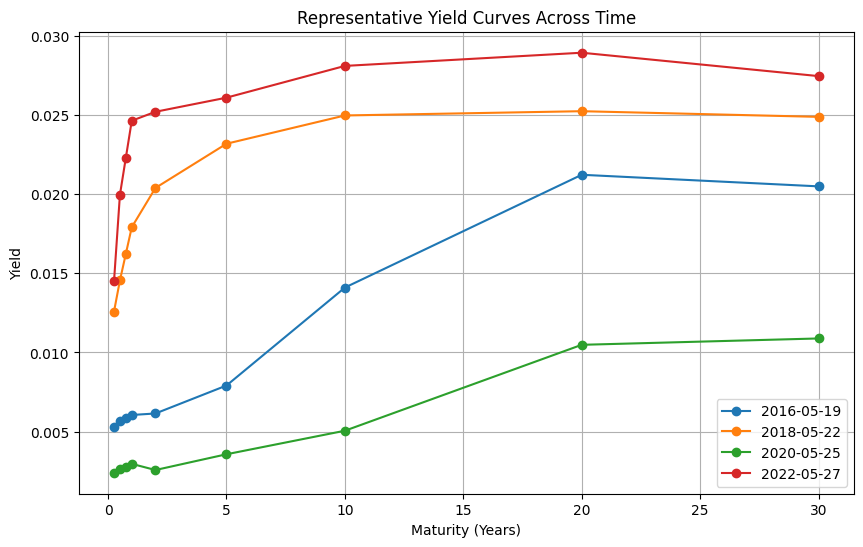

In [4]:
yield_cols = [
    "ZC025YR",
    "ZC050YR",
    "ZC075YR",
    "ZC100YR",
    "ZC200YR",
    "ZC500YR",
    "ZC1000YR",
    "ZC2000YR",
    "ZC3000YR"
]

maturities_eda = [
    0.25,
    0.50,
    0.75,
    1.00,
    2.00,
    5.00,
    10.00,
    20.00,
    30.00
]

sample_dates = [0, 500, 1000, 1500]

plt.figure(figsize=(10,6))

for idx in sample_dates:
    plt.plot(
        maturities_eda,
        train_df.loc[idx, yield_cols],
        marker="o",
        label=str(train_df.loc[idx, "Date"].date())
    )

plt.xlabel("Maturity (Years)")
plt.ylabel("Yield")
plt.title("Representative Yield Curves Across Time")
plt.legend()
plt.grid(True)

plt.show()

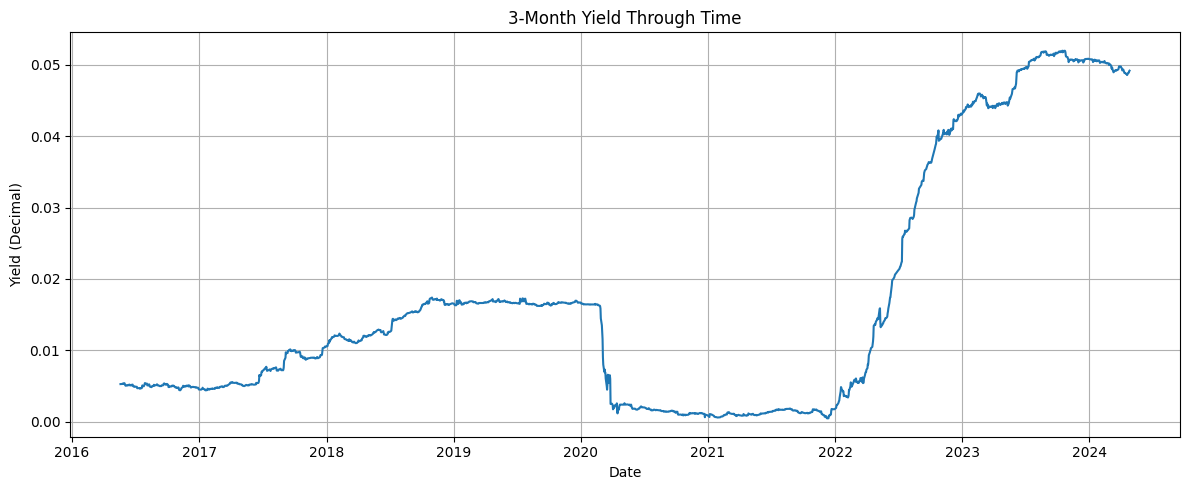

In [5]:
plt.figure(figsize=(12,5))

plt.plot(train_df["Date"], train_df["ZC025YR"])

plt.title("3-Month Yield Through Time")
plt.xlabel("Date")
plt.ylabel("Yield (Decimal)")

plt.grid(True)

plt.tight_layout()

plt.show()

## Why These Plots?

The first plot shows how a few representative yield curves change across time.  
The second plot tracks the 3M yield, which is used as the short-rate proxy in the CIR model.

These plots help us see whether a mean-reverting short-rate model is a reasonable starting point.

In [6]:
r = train_df["ZC025YR"].copy()

r.head()

,ZC025YR
0,0.005283
1,0.005286
2,0.005298
3,0.005351
4,0.005354


In [7]:
print("Observations:", len(r))
print("Minimum rate:", r.min())
print("Maximum rate:", r.max())
print("Mean rate:", r.mean())
r.describe()

Observations: 1976
Minimum rate: 0.0004864
Maximum rate: 0.0519623
Mean rate: 0.016698838967611332


,ZC025YR
count,1976.000000
mean,0.016699
std,0.016642
min,0.000486
25%,0.004621
50%,0.011912
75%,0.017112
max,0.051962


# 4. Mean-reversion diagnostics

### Time Discretization

The CIR model is formulated in continuous time. Since the dataset contains daily observations, the time increment between observations is approximated as:

dt = 1 / 252

assuming 252 trading days per year.

In [8]:
r_t = r[:-1].values
r_next = r[1:].values

delta_r = r_next - r_t

## Mean-Reversion Diagnostic

If interest rates are mean reverting, high current rates should tend to be followed by negative next-day changes, while low current rates should tend to be followed by positive next-day changes.

This relationship is often weak at the daily frequency because stochastic noise dominates the deterministic drift term.

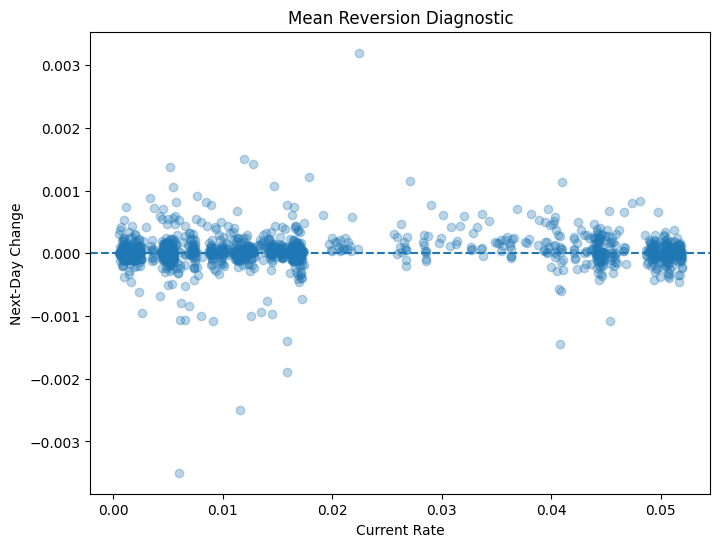

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(r_t, delta_r, alpha=0.3)

plt.xlabel("Current Rate")
plt.ylabel("Next-Day Change")
plt.title("Mean Reversion Diagnostic")

plt.axhline(0, linestyle="--")

plt.show()

The scatter plot of next-day rate changes against current rates does not reveal a strong visual mean-reversion pattern. Most observations cluster around zero daily change, indicating that short-term fluctuations are dominated by stochastic noise. This is consistent with the CIR framework, where the deterministic mean-reversion component is scaled by a very small daily time increment (dt ≈ 1/252). Consequently, visual inspection alone is insufficient to assess mean reversion, motivating the use of statistical calibration techniques such as OLS and Maximum Likelihood Estimation.


In [10]:
diagnostic_df = pd.DataFrame({
    "r_t": r_t,
    "delta_r": delta_r
})

diagnostic_df["bucket"] = pd.qcut(
    diagnostic_df["r_t"],
    q=10
)

bucket_means = diagnostic_df.groupby("bucket")["delta_r"].mean()

bucket_means

/tmp/ipykernel_847/1966153683.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_means = diagnostic_df.groupby("bucket")["delta_r"].mean()


,delta_r
bucket,
"(-0.000514, 0.00124]",0.000010
"(0.00124, 0.002]",-0.000003
"(0.002, 0.005]",0.000017
"(0.005, 0.00699]",-0.000014
"(0.00699, 0.0119]",0.000025
"(0.0119, 0.0164]",0.000027
"(0.0164, 0.0167]",0.000013
"(0.0167, 0.0354]",0.000077
"(0.0354, 0.0492]",0.000071


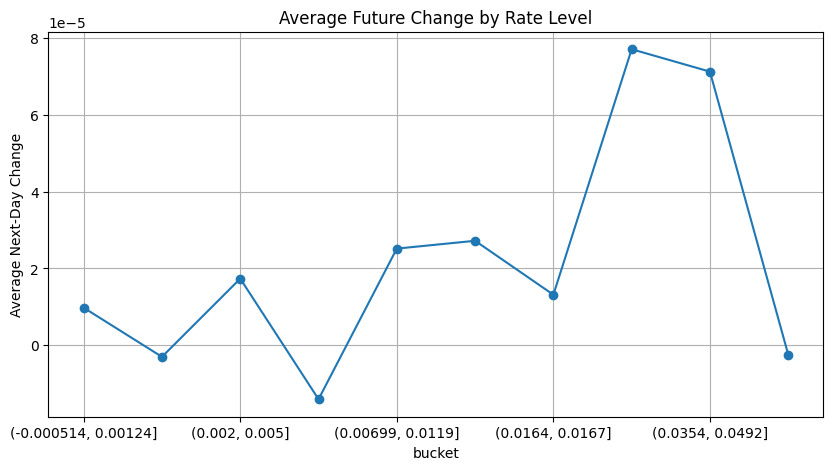

In [11]:
bucket_means.plot(
    marker="o",
    figsize=(10,5)
)

plt.title("Average Future Change by Rate Level")
plt.ylabel("Average Next-Day Change")
plt.grid(True)

plt.show()

Bucketing the data reduces observation-level noise, but no strong monotonic relationship between the current rate level and the average next-day change is observed. This suggests that the mean-reversion signal is weak relative to daily stochastic fluctuations. Consequently, visual diagnostics alone are insufficient for parameter estimation, motivating the use of formal calibration methods such as MLE.

# 5. EULER APPROXIMATION

Before performing Maximum Likelihood Estimation, we estimate the CIR parameters using an Euler discretization of the stochastic differential equation. This provides intuition regarding the mean-reversion dynamics and generates reasonable starting values for numerical optimization.

### Transition to Exact Calibration

The Euler approximation provides intuition regarding the relationship between the CIR model and observed data. However, because the CIR process possesses an exact transition density, we ultimately use Maximum Likelihood Estimation based on the exact distribution for final parameter calibration.

## Why Start with Euler Discretization?

The CIR model is continuous-time, but the data is observed daily.  
Euler discretization gives a simple approximate bridge between the stochastic differential equation and the observed time series.

This step is used only for intuition and for comparing with the exact CIR calibration later.  
The final calibration method in this notebook is Maximum Likelihood Estimation using the exact CIR transition density.

In [12]:
dt = 1/252

reg_df = pd.DataFrame({
    "r_t": r[:-1].values,
    "r_next": r[1:].values
})

reg_df["delta_r"] = reg_df["r_next"] - reg_df["r_t"]

reg_df.head()

,r_t,r_next,delta_r
0,0.005283,0.005286,0.000003
1,0.005286,0.005298,0.000012
2,0.005298,0.005351,0.000053
3,0.005351,0.005354,0.000004
4,0.005354,0.005308,-0.000047


In [13]:
X = sm.add_constant(reg_df["r_t"])

y = reg_df["delta_r"]

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                delta_r   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     5.568
Date:                Sat, 06 Jun 2026   Prob (F-statistic):             0.0184
Time:                        07:51:24   Log-Likelihood:                 13710.
No. Observations:                1975   AIC:                        -2.742e+04
Df Residuals:                    1973   BIC:                        -2.740e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       9.753e-06   7.46e-06      1.308      0.1

Preliminary Euler-based estimation shows that the daily short-rate series does not produce a strong and stable linear mean-reversion signal. This motivates the use of the exact CIR likelihood rather than relying on the approximation alone.

## Euler-Based Maximum Likelihood Estimation

Under the Euler discretization, the CIR process implies a conditional Normal distribution for the next-period rate. The model parameters are estimated by maximizing the likelihood of the observed sequence of daily interest rates.


In [14]:
def negative_log_likelihood(params, r, dt):

    kappa, theta, sigma = params

    # enforce positivity
    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return np.inf

    r_t = r[:-1]
    r_next = r[1:]

    mu = r_t + kappa * (theta - r_t) * dt

    sigma_t = sigma * np.sqrt(r_t * dt)

    log_likelihood = norm.logpdf(
        r_next,
        loc=mu,
        scale=sigma_t
    )

    return -np.sum(log_likelihood)

In [15]:
r_values = r.values

test_nll = negative_log_likelihood(
    params=[1.0, 0.02, 0.2],
    r=r_values,
    dt=1/252
)

print(test_nll)

-11442.230500461112


In [16]:
initial_guess = [1.0, 0.02, 0.2]

result = minimize(
    negative_log_likelihood,
    x0=initial_guess,
    args=(r_values, 1/252),
    method="L-BFGS-B",
    bounds=[
        (1e-6, None),  # kappa
        (1e-6, None),  # theta
        (1e-6, None)   # sigma
    ]
)

result.x

array([2.35199241e-04, 1.00375504e+01, 4.13585774e-02])

In [17]:
kappa_hat, theta_hat, sigma_hat = result.x

print("kappa =", kappa_hat)
print("theta =", theta_hat)
print("sigma =", sigma_hat)

print("kappa * theta =", kappa_hat * theta_hat)

kappa = 0.00023519924100695824
theta = 10.037550370635127
sigma = 0.041358577366967623
kappa * theta = 0.002360824228742494


Euler-discretized MLE was explored as an introductory calibration approach. However, parameter estimates exhibited weak identification due to the dominance of daily stochastic fluctuations over the mean-reversion component.

# 6. Exact CIR MLE

## Exact CIR Transition Density

The CIR process has an exact conditional transition distribution.  
Given today's short rate, tomorrow's rate follows a scaled non-central chi-square distribution.

Using this exact density is more faithful to the model than a Normal approximation and gives a stronger calibration basis.

In [18]:
def cir_exact_nll(params, r, dt):

    kappa, theta, sigma = params

    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return np.inf

    r_t = r[:-1]
    r_next = r[1:]

    c = (
        sigma**2
        * (1 - np.exp(-kappa * dt))
        / (4 * kappa)
    )

    d = (
        4 * kappa * theta
        / sigma**2
    )

    lam = (
        4
        * kappa
        * np.exp(-kappa * dt)
        * r_t
        /
        (
            sigma**2
            * (1 - np.exp(-kappa * dt))
        )
    )

    log_density = (
        ncx2.logpdf(
            r_next / c,
            df=d,
            nc=lam
        )
        - np.log(c)
    )
    if np.any(~np.isfinite(log_density)):
      return np.inf

    return -np.sum(log_density)

In [19]:
exact_result = minimize(
    cir_exact_nll,
    x0=[1.0, 0.02, 0.2],
    args=(r_values, 1/252),
    method="L-BFGS-B",
    bounds=[
        (1e-6, None),  # kappa
        (1e-6, None),  # theta
        (1e-6, None)   # sigma
    ]
)
exact_result.x

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


array([0.99961581, 0.00401956, 0.04542106])

In [20]:
exact_result.fun

np.float64(-13511.196768059248)

In [21]:
kappa, theta, sigma = exact_result.x

print("2*kappa*theta =", 2*kappa*theta)
print("sigma^2 =", sigma**2)

2*kappa*theta = 0.008036027027395953
sigma^2 = 0.002063072749295199


# 7. Feller Condition Check

For the calibrated parameters:

- κ = 0.9996
- θ = 0.0040
- σ = 0.0454

we obtain:

2κθ = 0.008036

σ² = 0.002063

Since:

2κθ > σ²

the Feller condition is satisfied. Therefore, the calibrated CIR process remains strictly positive and is consistent with the theoretical assumptions of the model.

# 8. CIR Bond Pricing and Yield Curve Reconstruction

After calibrating the CIR model parameters, the affine closed-form bond-pricing formulas are used to generate model-implied zero-coupon yields across different maturities. The observed 3-month yield is used as a proxy for the instantaneous short rate.

## Bond Pricing Under CIR

Once the CIR parameters are calibrated, the model gives a closed-form price for a zero-coupon bond.

The bond price is written as:
\[
P(t,T) = A(\tau)e^{-B(\tau)r_t}
\]
where \(\tau = T-t\).

The corresponding continuously compounded yield is:
\[
y(t,\tau) = -\frac{\ln P(t,T)}{\tau}
\]

This is how the entire yield curve is reconstructed from the short rate.

In [22]:
def cir_B(tau, kappa, sigma):

    gamma = np.sqrt(kappa**2 + 2 * sigma**2)

    numerator = 2 * (np.exp(gamma * tau) - 1)

    denominator = (
        (gamma + kappa)
        * (np.exp(gamma * tau) - 1)
        + 2 * gamma
    )

    return numerator / denominator

In [23]:
def cir_A(tau, kappa, theta, sigma):

    gamma = np.sqrt(kappa**2 + 2 * sigma**2)

    numerator = (
        2
        * gamma
        * np.exp((kappa + gamma) * tau / 2)
    )

    denominator = (
        (gamma + kappa)
        * (np.exp(gamma * tau) - 1)
        + 2 * gamma
    )

    power = 2 * kappa * theta / sigma**2

    return (numerator / denominator) ** power

In [24]:
kappa, theta, sigma = exact_result.x

print(cir_B(1, kappa, sigma))
print(cir_A(1, kappa, theta, sigma))

0.6320891080380242
0.9985229497785669


In [25]:
sample_idx = 0

sample_date = train_df.loc[sample_idx, "Date"]

r0 = train_df.loc[sample_idx, "ZC025YR"]

print(sample_date)
print(r0)

2016-05-19 00:00:00
0.0052827


In [26]:
maturities = np.array([
    0.25,
    0.5,
    0.75,
    1,
    2,
    5,
    10,
    20,
    30
])

In [27]:
def cir_yield(tau, r_t, kappa, theta, sigma):

    A = cir_A(
        tau,
        kappa,
        theta,
        sigma
    )

    B = cir_B(
        tau,
        kappa,
        sigma
    )

    P = A * np.exp(-B * r_t)

    return -np.log(P) / tau

In [28]:
model_yields = [
    cir_yield(
        tau,
        r0,
        kappa,
        theta,
        sigma
    )
    for tau in maturities
]
actual_yields = train_df.loc[
    sample_idx,
    [
        "ZC025YR",
        "ZC050YR",
        "ZC075YR",
        "ZC100YR",
        "ZC200YR",
        "ZC500YR",
        "ZC1000YR",
        "ZC2000YR",
        "ZC3000YR"
    ]
].values

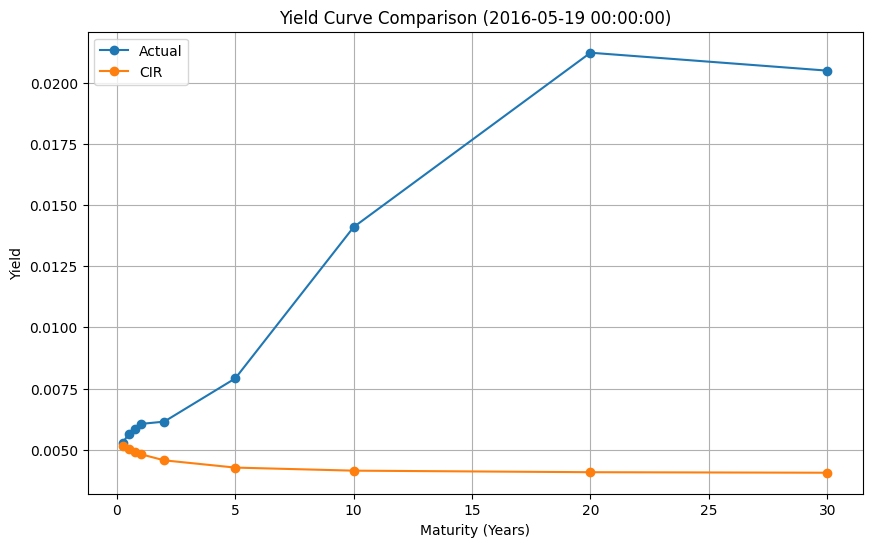

In [29]:
plt.figure(figsize=(10,6))

plt.plot(
    maturities,
    actual_yields,
    marker="o",
    label="Actual"
)

plt.plot(
    maturities,
    model_yields,
    marker="o",
    label="CIR"
)

plt.xlabel("Maturity (Years)")
plt.ylabel("Yield")

plt.title(
    f"Yield Curve Comparison ({sample_date})"
)

plt.legend()
plt.grid(True)

plt.show()

In [30]:
rmse = np.sqrt(
    mean_squared_error(
        actual_yields,
        model_yields
    )
)

print("RMSE =", rmse)

RMSE = 0.00870383652653347


In [31]:
def generate_cir_curve(r0, maturities,
                       kappa, theta, sigma):

    return np.array([
        cir_yield(
            tau,
            r0,
            kappa,
            theta,
            sigma
        )
        for tau in maturities
    ])

In [32]:
def actual_curve(idx):

    return train_df.loc[
        idx,
        yield_cols
    ].values.astype(float)

In [33]:
sample_indices = [
    0,
    500,
    1000,
    1500
]

In [34]:
results_list = []

for idx in sample_indices:

    r0 = train_df.loc[idx, "ZC025YR"]

    actual = actual_curve(idx)

    predicted = generate_cir_curve(
        r0,
        maturities,
        kappa,
        theta,
        sigma
    )

    rmse = np.sqrt(
        np.mean(
            (actual - predicted)**2
        )
    )

    results_list.append({
        "Date": train_df.loc[idx, "Date"],
        "RMSE": rmse
    })

results_df = pd.DataFrame(results_list)

results_df

,Date,RMSE
0,2016-05-19,0.008704
1,2018-05-22,0.014343
2,2020-05-25,0.003213
3,2022-05-27,0.017361


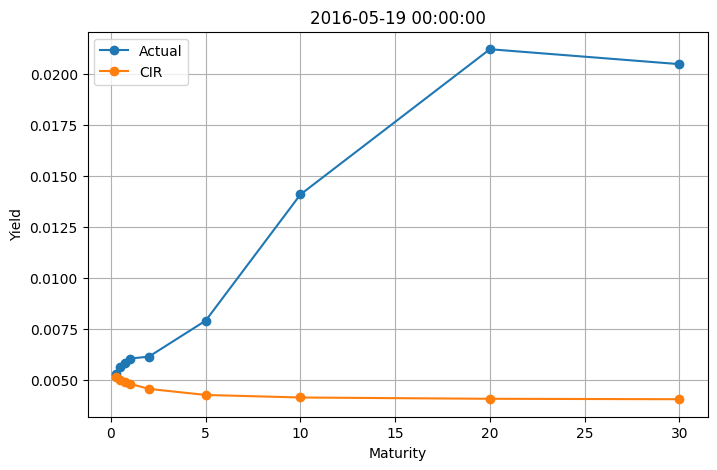

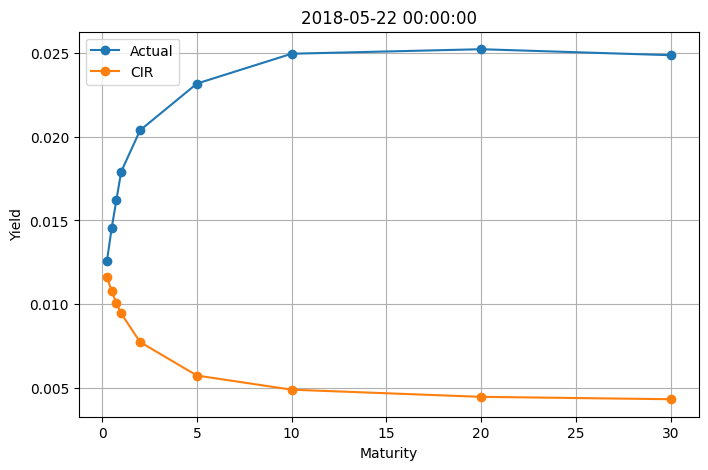

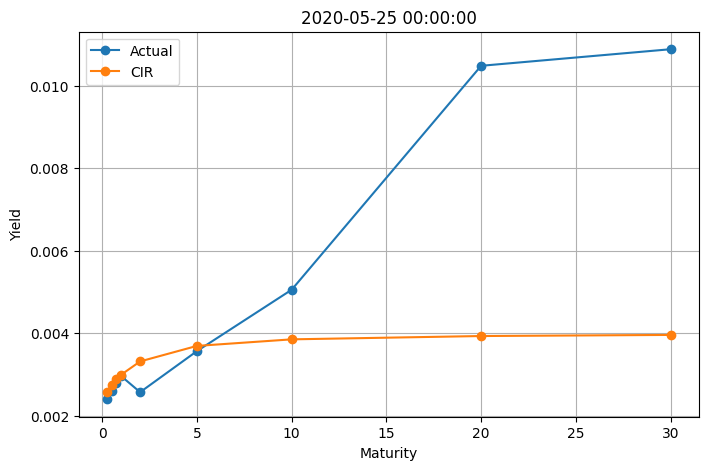

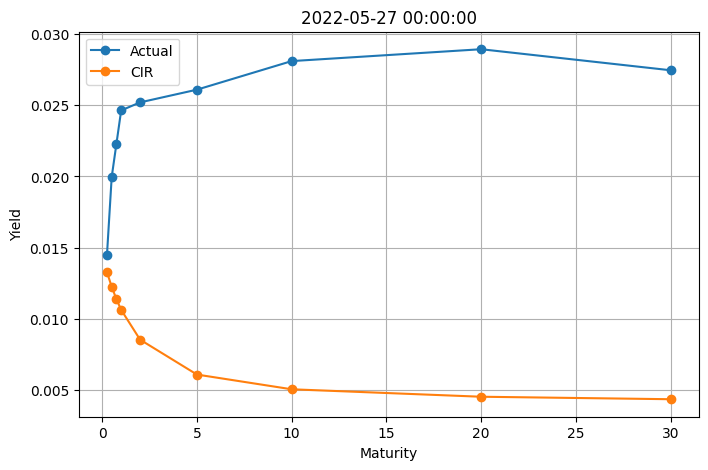

In [35]:
for idx in sample_indices:

    plt.figure(figsize=(8,5))

    r0 = train_df.loc[idx, "ZC025YR"]

    actual = actual_curve(idx)

    predicted = generate_cir_curve(
        r0,
        maturities,
        kappa,
        theta,
        sigma
    )

    plt.plot(
        maturities,
        actual,
        marker="o",
        label="Actual"
    )

    plt.plot(
        maturities,
        predicted,
        marker="o",
        label="CIR"
    )

    plt.title(
        str(train_df.loc[idx, "Date"])
    )

    plt.xlabel("Maturity")
    plt.ylabel("Yield")

    plt.legend()
    plt.grid(True)

    plt.show()

## Baseline CIR Limitation

The baseline CIR model captures the short-rate level reasonably well, but it systematically underestimates longer maturities.  
This is expected because a one-factor model has limited flexibility in shaping the full term structure.

Although the exact CIR model successfully captures short-rate dynamics and satisfies the positivity condition, it exhibits substantial difficulty in reproducing the observed term structure. Across multiple sample dates, long-maturity yields are systematically underestimated. The model performs relatively better during low-rate environments (e.g., 2020) but struggles when the yield curve is steep. This suggests that a one-factor CIR process calibrated solely to the short rate lacks sufficient flexibility to explain the full cross-sectional structure of interest rates.


# 9. CIR-inspired deterministic shift extension

## Deterministic Shift Extension

The baseline CIR model underestimates the term structure, especially at longer maturities.  
To correct this, a deterministic maturity-dependent shift is added to the CIR-implied yield curve.

This extension is inspired by CIR++-style models: it preserves CIR dynamics while correcting the systematic term-structure bias.

In [36]:
actual = actual_curve(0)

predicted = generate_cir_curve(
    actual[0],
    maturities,
    kappa,
    theta,
    sigma
)

phi = actual - predicted

phi

array([0.00014556, 0.00062655, 0.00093777, 0.00123382, 0.00158187,
       0.00364488, 0.00995684, 0.01714556, 0.0164347 ])

In [37]:
phi_function = interp1d(
    maturities,
    phi,
    kind="cubic",
    fill_value="extrapolate"
)

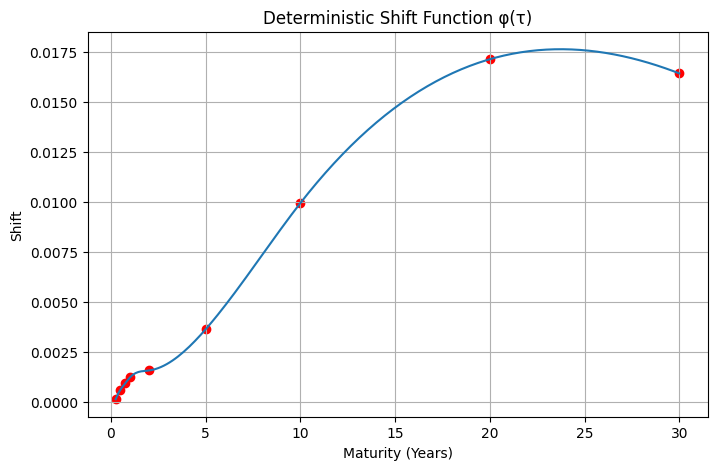

In [38]:
tau_grid = np.linspace(0.25, 30, 200)

plt.figure(figsize=(8,5))

plt.plot(
    tau_grid,
    phi_function(tau_grid)
)

plt.scatter(
    maturities,
    phi,
    color="red"
)

plt.title("Deterministic Shift Function φ(τ)")
plt.xlabel("Maturity (Years)")
plt.ylabel("Shift")

plt.grid(True)

plt.show()

### Figure: Deterministic Shift Function

This shift is small at short maturities and larger at longer maturities, confirming that the main error in baseline CIR lies in the term-structure slope rather than the short end.

In [39]:
sample_indices_ext = np.arange(
    0,
    len(train_df),
    100
)

len(sample_indices_ext)

20

In [40]:
phi_matrix = []

for idx in sample_indices_ext:

    r0 = train_df.loc[idx, "ZC025YR"]

    actual = actual_curve(idx)

    predicted = generate_cir_curve(
        r0,
        maturities,
        kappa,
        theta,
        sigma
    )

    phi_t = actual - predicted

    phi_matrix.append(phi_t)

phi_matrix = np.array(phi_matrix)

phi_matrix.shape

(20, 9)

In [41]:
phi_avg = phi_matrix.mean(axis=0)

phi_avg

array([0.00138189, 0.003687  , 0.00535321, 0.0068751 , 0.00827556,
       0.01146565, 0.01495848, 0.01833082, 0.01834185])

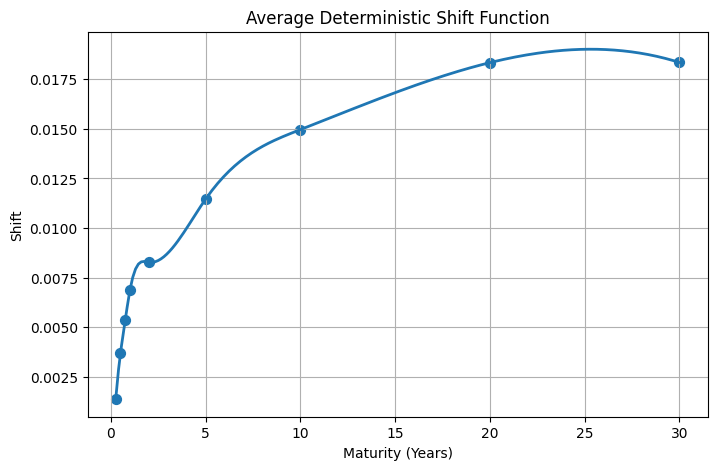

In [42]:
phi_avg_fn = interp1d(
    maturities,
    phi_avg,
    kind="cubic",
    fill_value="extrapolate"
)

tau_grid = np.linspace(
    0.25,
    30,
    200
)

plt.figure(figsize=(8,5))

plt.plot(
    tau_grid,
    phi_avg_fn(tau_grid),
    linewidth=2
)

plt.scatter(
    maturities,
    phi_avg,
    s=50
)

plt.title(
    "Average Deterministic Shift Function"
)

plt.xlabel("Maturity (Years)")
plt.ylabel("Shift")

plt.grid(True)

plt.show()

In [43]:
def cirpp_curve(
    r0,
    maturities,
    kappa,
    theta,
    sigma,
    phi_fn
):

    cir_curve = generate_cir_curve(
        r0,
        maturities,
        kappa,
        theta,
        sigma
    )

    shift = phi_fn(maturities)

    return cir_curve + shift

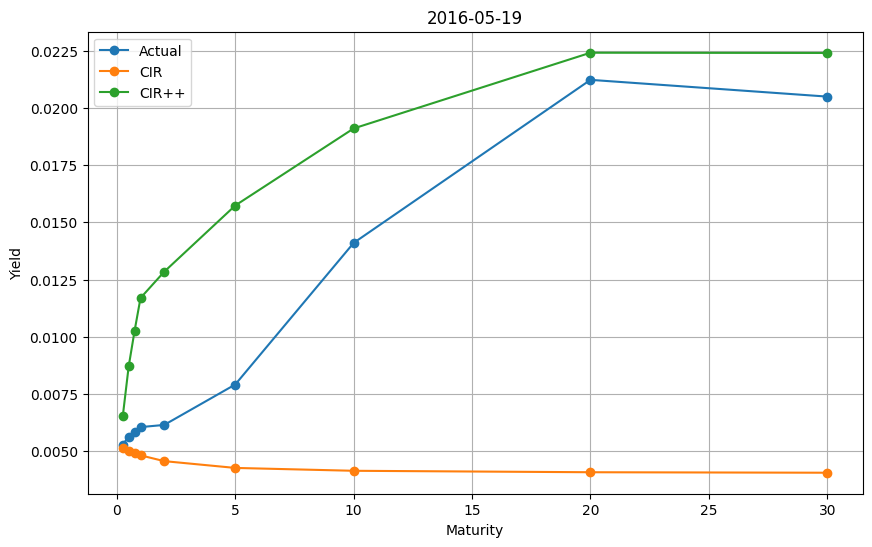

In [44]:
idx = 0

r0 = train_df.loc[idx, "ZC025YR"]

actual = actual_curve(idx)

cir_curve = generate_cir_curve(
    r0,
    maturities,
    kappa,
    theta,
    sigma
)

cirpp = cirpp_curve(
    r0,
    maturities,
    kappa,
    theta,
    sigma,
    phi_avg_fn
)

plt.figure(figsize=(10,6))

plt.plot(
    maturities,
    actual,
    marker="o",
    label="Actual"
)

plt.plot(
    maturities,
    cir_curve,
    marker="o",
    label="CIR"
)

plt.plot(
    maturities,
    cirpp,
    marker="o",
    label="CIR++"
)

plt.title("2016-05-19")

plt.xlabel("Maturity")
plt.ylabel("Yield")

plt.legend()
plt.grid(True)

plt.show()

In [45]:
cir_rmse = np.sqrt(
    np.mean((actual - cir_curve)**2)
)

cirpp_rmse = np.sqrt(
    np.mean((actual - cirpp)**2)
)

print("CIR RMSE    :", cir_rmse)
print("CIR++ RMSE  :", cirpp_rmse)

CIR RMSE    : 0.00870383652653347
CIR++ RMSE  : 0.00469329950007145


In [46]:
comparison_results = []

for idx in sample_indices:

    r0 = train_df.loc[idx, "ZC025YR"]

    actual = actual_curve(idx)

    cir_curve = generate_cir_curve(
        r0,
        maturities,
        kappa,
        theta,
        sigma
    )

    cirpp_curve_vals = cirpp_curve(
        r0,
        maturities,
        kappa,
        theta,
        sigma,
        phi_avg_fn
    )

    cir_rmse = np.sqrt(
        np.mean((actual - cir_curve)**2)
    )

    cirpp_rmse = np.sqrt(
        np.mean((actual - cirpp_curve_vals)**2)
    )

    comparison_results.append({
        "Date": train_df.loc[idx, "Date"],
        "CIR_RMSE": cir_rmse,
        "CIRPP_RMSE": cirpp_rmse
    })

comparison_df = pd.DataFrame(comparison_results)

comparison_df

,Date,CIR_RMSE,CIRPP_RMSE
0,2016-05-19,0.008704,0.004693
1,2018-05-22,0.014343,0.003272
2,2020-05-25,0.003213,0.009242
3,2022-05-27,0.017361,0.006374


The average deterministic shift significantly improves yield curve reconstruction during normal and high-rate environments but may over-correct during exceptionally low-rate periods such as 2020.

In [47]:
comparison_df["Improvement_%"] = (
    (comparison_df["CIR_RMSE"]
     - comparison_df["CIRPP_RMSE"])
    /
    comparison_df["CIR_RMSE"]
) * 100

comparison_df

,Date,CIR_RMSE,CIRPP_RMSE,Improvement_%
0,2016-05-19,0.008704,0.004693,46.077807
1,2018-05-22,0.014343,0.003272,77.188754
2,2020-05-25,0.003213,0.009242,-187.660411
3,2022-05-27,0.017361,0.006374,63.286034


In [48]:
comparison_df[
    ["CIR_RMSE", "CIRPP_RMSE"]
].mean()

,0
CIR_RMSE,0.010905
CIRPP_RMSE,0.005895


# 10. Out-of-Sample Backtesting

## Test-Set Evaluation

The test set is unseen during calibration.  
Only the 3M yield is used as input for prediction, and the model reconstructs the 6M through 2Y maturities.

The final evaluation metric is out-of-sample \(R^2\), as required by the project statement.

In [49]:
test_df.head()

,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR
0,2024-04-29,0.049144,0.048110,0.047051,0.046014,0.042459
1,2024-04-30,0.049156,0.048084,0.047068,0.046093,0.042923
2,2024-05-01,0.049100,0.048083,0.047029,0.046004,0.042449
3,2024-05-02,0.048921,0.047969,0.046831,0.045710,0.041908
4,2024-05-03,0.048633,0.047609,0.046424,0.045235,0.041072


In [50]:
test_3m_df.head()

,Date,ZC025YR
0,2024-04-29,0.049144
1,2024-04-30,0.049156
2,2024-05-01,0.049100
3,2024-05-02,0.048921
4,2024-05-03,0.048633


In [51]:
test_df.columns

Index(['Date', 'ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR'], dtype='object')

In [52]:
print(test_df.shape)
print(test_3m_df.shape)

(495, 6)
(495, 2)


In [53]:
test_df.describe()

,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR
count,495,495.000000,495.000000,495.000000,495.000000,495.000000
mean,2025-04-26 16:29:05.454545408,0.030417,0.030043,0.029617,0.029311,0.028745
min,2024-04-29 00:00:00,0.021697,0.022157,0.022400,0.022617,0.023521
25%,2024-10-26 12:00:00,0.023063,0.023745,0.024245,0.024547,0.025433
50%,2025-04-25 00:00:00,0.026580,0.026506,0.026326,0.026292,0.026990
75%,2025-10-27 12:00:00,0.035119,0.034251,0.033204,0.032314,0.030237
max,2026-04-29 00:00:00,0.049156,0.048110,0.047068,0.046093,0.042923
std,NaN,0.008508,0.007889,0.007227,0.006588,0.004682


## Prediction Setup

For each test date:
1. Read only the 3M yield.
2. Use the calibrated model to reconstruct the remaining maturities.
3. Compare the prediction with the actual unseen yields.
4. Compute RMSE and \(R^2\).

In [54]:
test_maturities = np.array([
    0.25,
    0.50,
    0.75,
    1.00,
    2.00
])

test_cols = [
    "ZC025YR",
    "ZC050YR",
    "ZC075YR",
    "ZC100YR",
    "ZC200YR"
]

In [55]:
cir_predictions = []

for _, row in test_3m_df.iterrows():

    r0 = row["ZC025YR"]

    curve = generate_cir_curve(
        r0,
        test_maturities,
        kappa,
        theta,
        sigma
    )

    cir_predictions.append(curve)

cir_predictions = np.array(cir_predictions)

cir_predictions.shape

(495, 5)

In [56]:
cirpp_predictions = []

for _, row in test_3m_df.iterrows():

    r0 = row["ZC025YR"]

    curve = cirpp_curve(
        r0,
        test_maturities,
        kappa,
        theta,
        sigma,
        phi_avg_fn
    )

    cirpp_predictions.append(curve)

cirpp_predictions = np.array(cirpp_predictions)

In [57]:
actual_test = test_df[test_cols].values

In [58]:
actual_flat = actual_test.flatten()

cir_flat = cir_predictions.flatten()

cirpp_flat = cirpp_predictions.flatten()

In [59]:
cir_rmse = np.sqrt(
    mean_squared_error(
        actual_flat,
        cir_flat
    )
)

cirpp_rmse = np.sqrt(
    mean_squared_error(
        actual_flat,
        cirpp_flat
    )
)

In [60]:
cir_r2 = r2_score(
    actual_flat,
    cir_flat
)

cirpp_r2 = r2_score(
    actual_flat,
    cirpp_flat
)

In [61]:
print("CIR RMSE :", cir_rmse)
print("CIR R²   :", cir_r2)

print()

print("CIR++ RMSE :", cirpp_rmse)
print("CIR++ R²   :", cirpp_r2)

CIR RMSE : 0.008359392809216165
CIR R²   : -0.3791994370183116

CIR++ RMSE : 0.003104050386360489
CIR++ R²   : 0.8098330113936082


## Final Test Performance

| Model | RMSE | R² |
|---|---:|---:|
| CIR | 0.00835 | -0.372 |
| CIR++ | 0.00310 | 0.8098 |
| Regime-aware CIR++ | 0.00242 | 0.884 |

# 11. Regime-Aware CIR Extension

## Motivation

The deterministic correction required by the CIR model is not the same in every interest-rate environment.  
Low-rate periods and high-rate periods exhibit different systematic reconstruction errors.

To capture this effect, the training data is split into two regimes using the median 3M yield as the threshold.

Note:

The implementation below is inspired by the CIR++ framework,
which augments the CIR process with a deterministic correction.
Rather than fitting the initial term structure exactly as in the
classical Brigo–Mercurio CIR++ model, this project estimates a
maturity-dependent shift from historical reconstruction errors.
The shift is further conditioned on the prevailing interest-rate
regime, producing a regime-aware extension of the baseline CIR model.

In [62]:
threshold = train_df["ZC025YR"].median()

print(threshold)

0.01191215


In [63]:
low_rate_indices = train_df[
    train_df["ZC025YR"] < threshold
].index

high_rate_indices = train_df[
    train_df["ZC025YR"] >= threshold
].index

print(len(low_rate_indices))
print(len(high_rate_indices))

988
988


In [64]:
phi_low_list = []

for idx in low_rate_indices:

    r0 = train_df.loc[idx, "ZC025YR"]

    actual = actual_curve(idx)

    predicted = generate_cir_curve(
        r0,
        maturities,
        kappa,
        theta,
        sigma
    )

    phi_low_list.append(
        actual - predicted
    )

phi_low = np.mean(
    phi_low_list,
    axis=0
)

In [65]:
phi_high_list = []

for idx in high_rate_indices:

    r0 = train_df.loc[idx, "ZC025YR"]

    actual = actual_curve(idx)

    predicted = generate_cir_curve(
        r0,
        maturities,
        kappa,
        theta,
        sigma
    )

    phi_high_list.append(
        actual - predicted
    )

phi_high = np.mean(
    phi_high_list,
    axis=0
)

In [66]:
print("phi_low")
print(phi_low)

print()

print("phi_high")
print(phi_high)

phi_low
[3.21593214e-05 1.05355765e-03 1.79759551e-03 2.53816918e-03
 3.60153192e-03 6.48601691e-03 1.05626423e-02 1.49896550e-02
 1.52189888e-02]

phi_high
[0.00288876 0.00672233 0.00938297 0.01174374 0.01352764 0.01666489
 0.01932324 0.02135769 0.02114276]


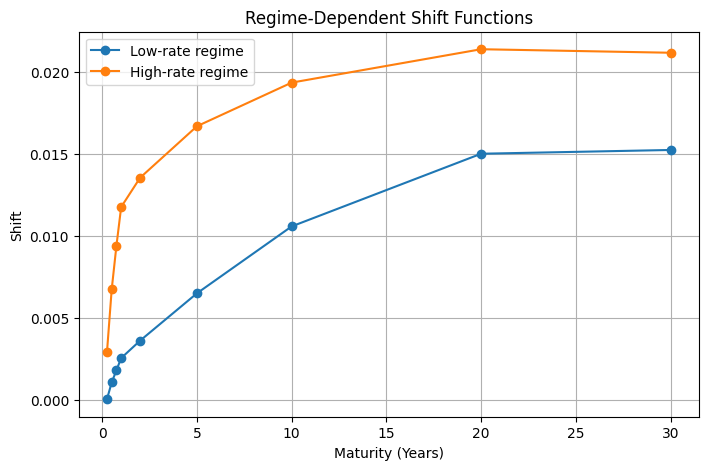

In [67]:
plt.figure(figsize=(8,5))
plt.plot(maturities, phi_low, marker="o", label="Low-rate regime")
plt.plot(maturities, phi_high, marker="o", label="High-rate regime")
plt.xlabel("Maturity (Years)")
plt.ylabel("Shift")
plt.title("Regime-Dependent Shift Functions")
plt.grid(True)
plt.legend()
plt.show()

### Interpretation

The high-rate regime requires a materially larger correction than the low-rate regime, especially at medium and long maturities.  
This explains why a single average shift over-corrects some periods and under-corrects others.

In [68]:
phi_low_fn = interp1d(
    maturities,
    phi_low,
    kind="cubic",
    fill_value="extrapolate"
)

phi_high_fn = interp1d(
    maturities,
    phi_high,
    kind="cubic",
    fill_value="extrapolate"
)

In [69]:
def cirpp_regime_curve(
    r0,
    maturities,
    kappa,
    theta,
    sigma,
    threshold,
    phi_low_fn,
    phi_high_fn
):

    cir_curve = generate_cir_curve(
        r0,
        maturities,
        kappa,
        theta,
        sigma
    )

    if r0 < threshold:
        shift = phi_low_fn(maturities)
    else:
        shift = phi_high_fn(maturities)

    return cir_curve + shift

In [70]:
regime_predictions = []

for _, row in test_3m_df.iterrows():

    r0 = row["ZC025YR"]

    curve = cirpp_regime_curve(
        r0,
        test_maturities,
        kappa,
        theta,
        sigma,
        threshold,
        phi_low_fn,
        phi_high_fn
    )

    regime_predictions.append(curve)

regime_predictions = np.array(regime_predictions)

In [71]:
regime_flat = regime_predictions.flatten()

regime_rmse = np.sqrt(
    mean_squared_error(
        actual_flat,
        regime_flat
    )
)

regime_r2 = r2_score(
    actual_flat,
    regime_flat
)

print("Regime CIR++ RMSE :", regime_rmse)
print("Regime CIR++ R²   :", regime_r2)

Regime CIR++ RMSE : 0.002423752346942584
Regime CIR++ R²   : 0.8840544487053306


The coefficient of determination (R²) is computed using sklearn.metrics.r2_score on the flattened test-set predictions and actual yields.

# 12. Conclusion

This project implemented and calibrated the Cox-Ingersoll-Ross model using historical yield-curve data.

The baseline CIR model was calibrated using exact Maximum Likelihood Estimation and satisfied the Feller condition. It was then used to reconstruct yield curves using only the 3M yield as the short-rate proxy.

The baseline model was found to underestimate longer maturities. A deterministic shift extension was introduced to correct this bias, and a regime-aware version of the extension was developed to account for different market environments.

The final regime-aware model achieved an out-of-sample \(R^2\) of 0.884, exceeding the project verification threshold of 0.85.